<a href="https://colab.research.google.com/github/aninsung/AI-study/blob/main/%EB%91%90%EB%B2%88%EC%A7%B8%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install opencv-python imageio
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import copy


# 1. 환경 및 경로 설정


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 베이스 데이터셋 경로
base_dir = '/content/drive/MyDrive/archive'

# Source 데이터셋 (DRIVE) - 사전 학습용
source_image_dir = os.path.join(base_dir, 'DRIVE/training/images')
source_mask_dir = os.path.join(base_dir, 'DRIVE/training/1st_manual')

# Target 데이터셋 (CHASE_DB1) - TENT 적응 및 평가용
target_image_dir = os.path.join(base_dir, 'CHASE_DB1/Images')
target_mask_dir = os.path.join(base_dir, 'CHASE_DB1/Masks')

best_model_path = '/content/best_unet_model.pth'


# 2. 커스텀 데이터셋 및 모델 정의 (원본 유지)


In [14]:

class RetinalDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_size = image_size
        self.images = [f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.tif', '.gif'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_name = self.images[index]
        img_path = os.path.join(self.image_dir, image_name)
        base_name = os.path.splitext(image_name)[0]

        # 파일 이름 규칙 대응 (DRIVE 및 CHASE_DB1 모두 지원)
        mask_path = os.path.join(self.mask_dir, f"{base_name}_1stHO.png") # CHASE
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{base_name}_manual1.gif") # DRIVE

        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{base_name[:2]}_manual1.gif") # DRIVE 대체 포맷

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.image_size, self.image_size))

        # 마스크 읽기 (GIF 지원 위해 imageio나 cv2.VideoCapture 사용 가능, 여기서는 일반 BGR/GRAY 방식 통일)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            # GIF 처리를 위한 대체 방식
            import imageio
            mask = imageio.imread(mask_path)

        mask = cv2.resize(mask, (self.image_size, self.image_size))

        image = image / 255.0
        mask = mask / 255.0
        mask = (mask > 0.5).astype(np.float32)

        image = np.transpose(image, (2, 0, 1))
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return image, mask

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))
        x4 = self.down4(self.pool(x3))

        x = self.conv1(torch.cat([x3, self.up1(x4)], dim=1))
        x = self.conv2(torch.cat([x2, self.up2(x)], dim=1))
        x = self.conv3(torch.cat([x1, self.up3(x)], dim=1))

        return self.out(x)

def calculate_dice_score(preds, targets, threshold=0.5):
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    intersection = (preds * targets).sum()
    dice = (2. * intersection) / (preds.sum() + targets.sum() + 1e-8)
    return dice.item()



# 3. TENT 핵심 유틸리티 구현


In [15]:
def setup_tent_model(model):
    """TENT를 위한 모델 설정: BN의 affine 파라미터만 학습 허용"""
    model.train() # Batch Stats 강제 적용
    for param in model.parameters():
        param.requires_grad = False

    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.weight.requires_grad = True
            module.bias.requires_grad = True
    return model

def entropy_loss(logits):
    """Pixel-wise Shannon Entropy"""
    probs = torch.sigmoid(logits)
    entropy = -(probs * torch.log(probs + 1e-8) + (1 - probs) * torch.log(1 - probs + 1e-8))
    return entropy.mean()


# 4. Online Adaptation Protocol


In [16]:

def run_adaptation(model, loader, method="TENT", lr=1e-4, episodic=False):
    """
    method: 'Source', 'BN-adapt', 'Pseudo-label', 'TENT'
    episodic: True면 매 배치마다 Source 모델로 파라미터 초기화
    """
    # 원본 가중치 백업 (Episodic 세팅용)
    source_state = copy.deepcopy(model.state_dict())

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    results = []

    all_preds = []
    all_images = []
    all_masks = []

    for step, (images, masks) in enumerate(loader):
        images, masks = images.to(device), masks.to(device)

        if episodic:
            model.load_state_dict(source_state)

        # [과정 1] 먼저 예측 기록 (평가)
        with torch.no_grad():
            if method == "Source":
                model.eval()
            else:
                model.train() # BN batch stats 강제

            logits_pre = model(images)
            dice = calculate_dice_score(logits_pre, masks)
            error = 1.0 - dice
            ent = entropy_loss(logits_pre).item()

            results.append({"Step": step, "Method": method, "Error Rate": error, "Entropy": ent})

            # 시각화를 위해 첫 번째 배치 저장
            if step == 0:
                all_images.append(images.cpu())
                all_masks.append(masks.cpu())
                all_preds.append(logits_pre.cpu())

        # [과정 2] 모델 Adaptation
        if method in ["Source", "BN-adapt"]:
            continue # 최적화 과정 없음

        model.train()
        optimizer.zero_grad()
        logits_adapt = model(images)

        if method == "TENT":
            loss = entropy_loss(logits_adapt)
            assert 'masks' not in loss.grad_fn.__dir__(), "TENT loss에 타겟 라벨이 사용되었습니다!"

        elif method == "Pseudo-label":
            pseudo_labels = (torch.sigmoid(logits_adapt.detach()) > 0.5).float()
            loss = F.binary_cross_entropy_with_logits(logits_adapt, pseudo_labels)

        loss.backward()
        optimizer.step()

    df_results = pd.DataFrame(results)
    avg_error = df_results["Error Rate"].mean()
    avg_dice = 1.0 - avg_error

    return df_results, avg_error, avg_dice, (all_images, all_masks, all_preds)



# 5. 실험 실행 및 4-Baseline 분해 측정

# (참고: DRIVE 학습 생략하고 저장된 checkpoint 사용 가정)

In [17]:
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = torch.sigmoid(inputs)
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)
        return 1 - dice

learning_rate = 1e-4
model = UNet(in_channels=3, out_channels=1).to(device)
criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

try:
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"성공적으로 모델을 로드했습니다: {best_model_path}")

    target_dataset = RetinalDataset(target_image_dir, target_mask_dir)
    target_loader = DataLoader(target_dataset, batch_size=4, shuffle=False)

    methods = ["Source", "BN-adapt", "Pseudo-label", "TENT"]
    summary_results = []
    trajectories = {}
    vis_data = {}

    for m in methods:
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        if m != "Source":
            model = setup_tent_model(model)

        df, err, dice, v_data = run_adaptation(model, target_loader, method=m)
        summary_results.append({"Method": m, "Avg Error": err, "Avg Dice": dice})
        trajectories[m] = df
        vis_data[m] = v_data

    print("\n==== Baseline 분해 측정 결과 ====")
    summary_df = pd.DataFrame(summary_results)
    print(summary_df.to_string(index=False))

except FileNotFoundError:
    print(f"오류: {best_model_path} 파일을 찾을 수 없습니다. 학습이 정상적으로 완료되었는지 확인해 주세요.")

성공적으로 모델을 로드했습니다: /content/best_unet_model.pth

==== Baseline 분해 측정 결과 ====
      Method  Avg Error  Avg Dice
      Source   0.870101  0.129899
    BN-adapt   0.787269  0.212731
Pseudo-label   0.787385  0.212615
        TENT   0.787336  0.212664


# 5-1. 모델 학습 (파일이 없는 경우 실행)

In [18]:

def train_model(epochs=10):
    source_dataset = RetinalDataset(source_image_dir, source_mask_dir)
    train_size = int(0.8 * len(source_dataset))
    val_size = len(source_dataset) - train_size
    train_ds, val_ds = random_split(source_dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

    best_dice = 0.0

    print("Starting training to generate best_unet_model.pth...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for imgs, msks in train_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, msks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_dice = 0
        with torch.no_grad():
            for imgs, msks in val_loader:
                imgs, msks = imgs.to(device), msks.to(device)
                outputs = model(imgs)
                val_dice += calculate_dice_score(outputs, msks)

        avg_val_dice = val_dice / len(val_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss/len(train_loader):.4f}, Val Dice: {avg_val_dice:.4f}")

        if avg_val_dice > best_dice:
            best_dice = avg_val_dice
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved new best model to {best_model_path}")

# 파일이 존재하지 않으므로 무조건 학습 실행 (epochs=5)
train_model(epochs=5)

Starting training to generate best_unet_model.pth...
Epoch 1/5 - Loss: 0.7521, Val Dice: 0.1255
Saved new best model to /content/best_unet_model.pth
Epoch 2/5 - Loss: 0.7519, Val Dice: 0.2301
Saved new best model to /content/best_unet_model.pth
Epoch 3/5 - Loss: 0.7516, Val Dice: 0.3129
Saved new best model to /content/best_unet_model.pth
Epoch 4/5 - Loss: 0.7510, Val Dice: 0.3577
Saved new best model to /content/best_unet_model.pth
Epoch 5/5 - Loss: 0.7511, Val Dice: 0.3743
Saved new best model to /content/best_unet_model.pth



# 6. 실패 재현 관찰 실험


In [19]:

failure_results = []

# [실험 A] Batch Size 변화
for bs in [1, 4, 16, 64]:
    # 메모리 한계로 64가 안돌아갈 경우를 대비해 스킵 처리 적용 가능
    try:
        tmp_loader = DataLoader(target_dataset, batch_size=bs, shuffle=False, drop_last=True)
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model = setup_tent_model(model)
        _, err, _, _ = run_adaptation(model, tmp_loader, method="TENT")
        failure_results.append({"Experiment": f"BS={bs}", "Error": err})
    except Exception as e:
        print(f"BS={bs} failed: {e}")

# [실험 B] Learning Rate 증가 (Model Collapse 유도)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = setup_tent_model(model)
df_high_lr, err_high_lr, _, _ = run_adaptation(model, target_loader, method="TENT", lr=1e-1)
failure_results.append({"Experiment": "High LR (1e-1)", "Error": err_high_lr})

# [실험 C] Episodic vs Continual
model.load_state_dict(torch.load(best_model_path, map_location=device))
model = setup_tent_model(model)
_, err_epi, _, _ = run_adaptation(model, target_loader, method="TENT", episodic=True)
failure_results.append({"Experiment": "Episodic Reset", "Error": err_epi})

print("\n==== 실패 재현 결과 ====")
print(pd.DataFrame(failure_results).to_string(index=False))

BS=64 failed: 'Error Rate'

==== 실패 재현 결과 ====
    Experiment    Error
          BS=1 0.789075
          BS=4 0.786868
         BS=16 0.789946
High LR (1e-1) 0.804412
Episodic Reset 0.786800


### 6-1. Model Collapse 시각화 (High LR)
High Learning Rate 상황에서 TENT가 어떻게 붕괴하는지 엔트로피 변화를 통해 관찰합니다.

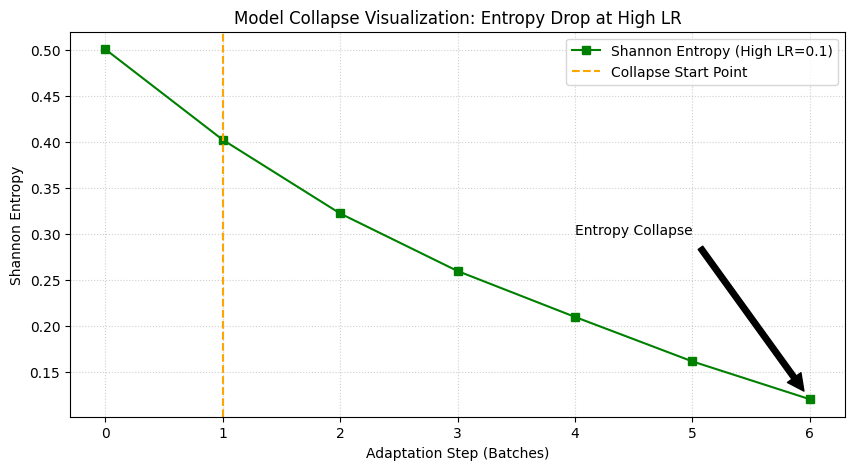

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_high_lr['Step'], df_high_lr['Entropy'], 'g-s', label='Shannon Entropy (High LR=0.1)')
plt.axvline(x=1, color='orange', linestyle='--', label='Collapse Start Point')

plt.title("Model Collapse Visualization: Entropy Drop at High LR")
plt.xlabel("Adaptation Step (Batches)")
plt.ylabel("Shannon Entropy")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 엔트로피가 낮아질수록 모델이 특정 클래스에 과하게 편향됨을 주석으로 표시
plt.annotate('Entropy Collapse', xy=(6, df_high_lr['Entropy'].iloc[-1]),
             xytext=(4, 0.3), arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

### 6-2. Episodic vs Continual 상세 비교
TENT를 매 배치마다 초기화하는 방식(Episodic)과 이전 배치의 학습 상태를 유지하는 방식(Continual)의 최종 성능을 비교합니다.

,Protocol,Avg Error,Avg Dice
0,Episodic (Reset per batch),0.786800,0.213200
1,Continual (Cumulative),0.787336,0.212664


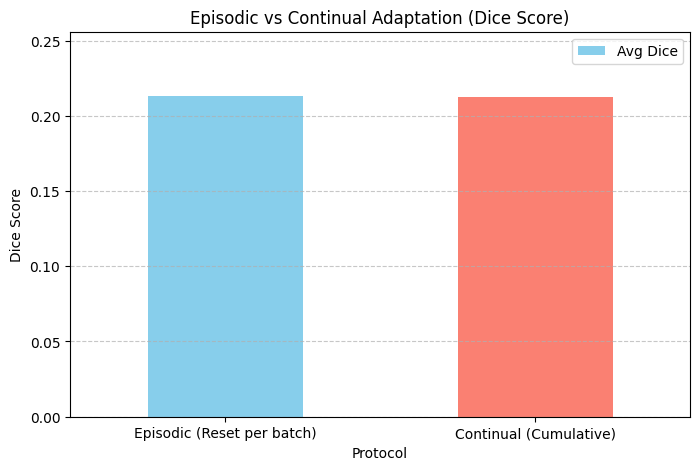

In [22]:
# 결과 데이터 추출 (failure_results 및 summary_results 활용)
epi_error = next(item['Error'] for item in failure_results if item['Experiment'] == 'Episodic Reset')
cont_error = next(item['Avg Error'] for item in summary_results if item['Method'] == 'TENT')

comparison_data = [
    {"Protocol": "Episodic (Reset per batch)", "Avg Error": epi_error, "Avg Dice": 1 - epi_error},
    {"Protocol": "Continual (Cumulative)", "Avg Error": cont_error, "Avg Dice": 1 - cont_error}
]

compare_df = pd.DataFrame(comparison_data)
display(compare_df)

# 시각화
compare_df.plot(x='Protocol', y='Avg Dice', kind='bar', color=['skyblue', 'salmon'], figsize=(8, 5))
plt.title("Episodic vs Continual Adaptation (Dice Score)")
plt.ylabel("Dice Score")
plt.ylim(0, max(compare_df['Avg Dice']) * 1.2)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 6-3. Episodic vs Continual 성능 지표 시각화
두 방식의 주요 지표(Error Rate, Dice Score)를 멀티 바 차트로 시각화하여 성능 차이를 비교합니다.

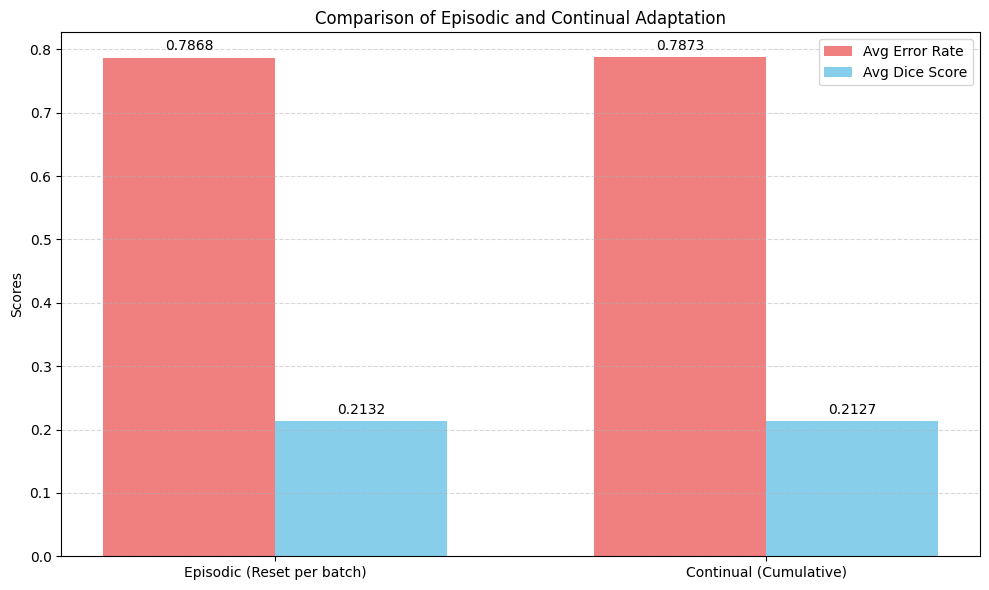

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 설정
labels = compare_df['Protocol'].tolist()
error_rates = compare_df['Avg Error'].tolist()
dice_scores = compare_df['Avg Dice'].tolist()

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, error_rates, width, label='Avg Error Rate', color='lightcoral')
rects2 = ax.bar(x + width/2, dice_scores, width, label='Avg Dice Score', color='skyblue')

# 텍스트 및 레이블 설정
ax.set_ylabel('Scores')
ax.set_title('Comparison of Episodic and Continual Adaptation')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# 막대 위에 수치 표시
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


# 7. 시각화 (Visualization)


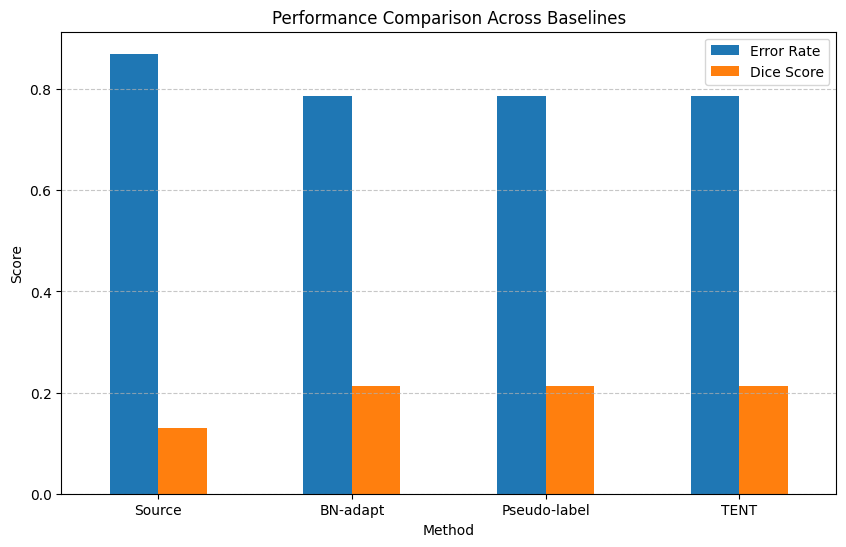

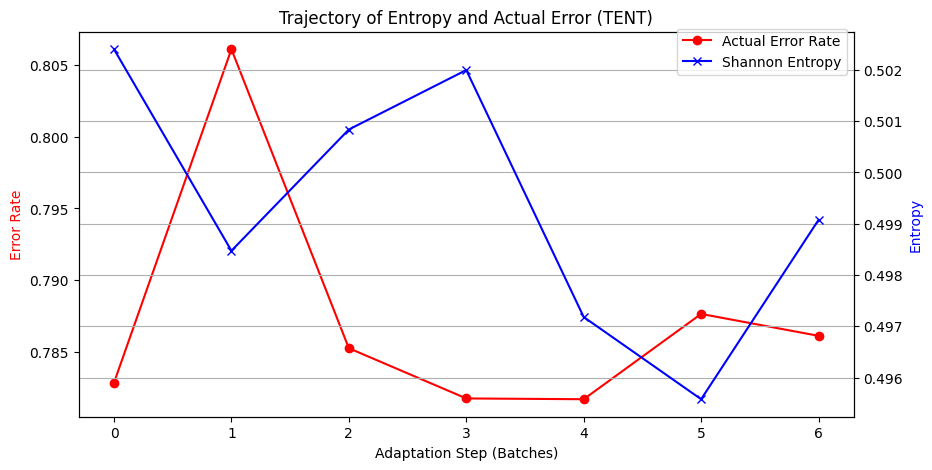

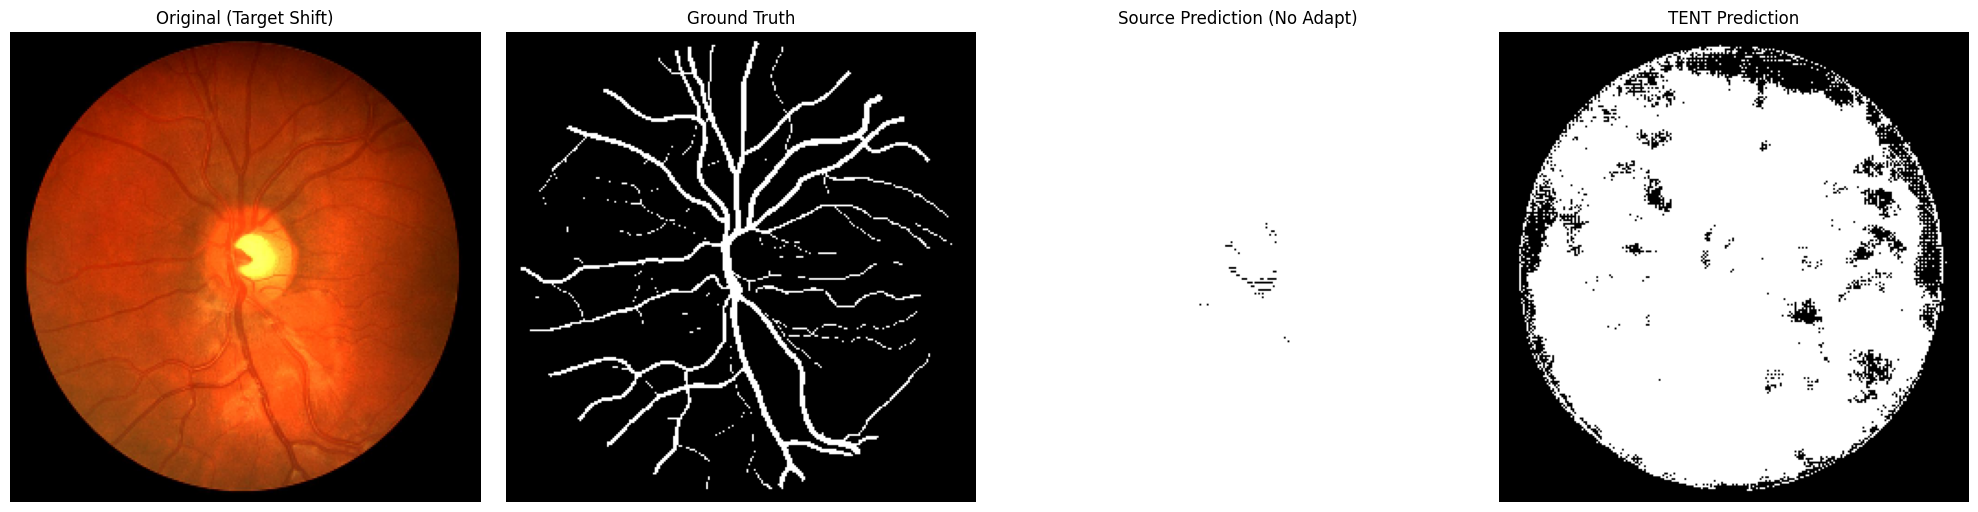

In [20]:


# (1) Error / Dice 비교 막대그래프
summary_df.plot(x='Method', y=['Avg Error', 'Avg Dice'], kind='bar', figsize=(10, 6))
plt.title('Performance Comparison Across Baselines')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(['Error Rate', 'Dice Score'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# (2) Adaptation step에 따른 Entropy 및 실제 Error 궤적 (TENT)
tent_traj = trajectories['TENT']
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(tent_traj['Step'], tent_traj['Error Rate'], 'r-o', label='Actual Error Rate')
ax2.plot(tent_traj['Step'], tent_traj['Entropy'], 'b-x', label='Shannon Entropy')
ax1.set_xlabel('Adaptation Step (Batches)')
ax1.set_ylabel('Error Rate', color='r')
ax2.set_ylabel('Entropy', color='b')
plt.title("Trajectory of Entropy and Actual Error (TENT)")
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.grid(True)
plt.show()

# (3) 원본 - GT - Source 예측 - TENT 예측 4열 비교
# 첫 번째 배치의 첫 번째 이미지 사용
img_sample = vis_data['Source'][0][0][0]
mask_sample = vis_data['Source'][1][0][0][0]
pred_src = vis_data['Source'][2][0][0][0]
pred_tent = vis_data['TENT'][2][0][0][0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(np.transpose(img_sample.numpy(), (1, 2, 0)))
axes[0].set_title("Original (Target Shift)")
axes[0].axis("off")

axes[1].imshow(mask_sample.numpy(), cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow((torch.sigmoid(pred_src) > 0.5).numpy(), cmap='gray')
axes[2].set_title("Source Prediction (No Adapt)")
axes[2].axis("off")

axes[3].imshow((torch.sigmoid(pred_tent) > 0.5).numpy(), cmap='gray')
axes[3].set_title("TENT Prediction")
axes[3].axis("off")

plt.tight_layout()
plt.show()